# 📊 Intern Performance Prediction Using Machine Learning

### Objective

The objective of this project is to predict the success probability of interns based on their attendance, task completion, mentor feedback, engagement level, and quality of work using Machine Learning techniques. The developed model helps mentors identify interns who may require additional support and personalized guidance.

## Step 1: Import Required Libraries

In this step, all the necessary Python libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Step 2: Load the Dataset

The internship performance dataset is loaded into the Jupyter Notebook using the Pandas library for further analysis and preprocessing.

In [2]:
df = pd.read_csv("intern_performance_dataset.csv")

## Step 3: Data Exploration

The dataset is explored to understand its structure, data types, dimensions, and statistical summary before applying machine learning algorithms.

In [3]:
df.head()

,Intern_ID,Department,Attendance(%),Tasks_Assigned,Tasks_Completed,Task_Completion_Rate(%),Mentor_Feedback_Score(1-10),Engagement_Score(1-10),Quality_of_Work_Score(1-10),Success_Probability,Performance_Label
0,1001,Frontend Development,77,14,8,57.1,6.5,3.7,6.4,0.55,Medium
1,1002,Digital Marketing,75,14,7,50.0,6.3,5.5,4.1,0.67,Medium
2,1003,Digital Marketing,97,12,7,58.3,6.7,5.5,5.7,0.72,High
3,1004,UI/UX Design,62,11,6,54.5,3.2,2.8,3.6,0.38,Low
4,1005,Cybersecurity,60,15,8,53.3,5.3,6.1,4.2,0.58,Medium


In [4]:
df.shape

(200, 11)

In [5]:
df.columns

Index(['Intern_ID', 'Department', 'Attendance(%)', 'Tasks_Assigned',
       'Tasks_Completed', 'Task_Completion_Rate(%)',
       'Mentor_Feedback_Score(1-10)', 'Engagement_Score(1-10)',
       'Quality_of_Work_Score(1-10)', 'Success_Probability',
       'Performance_Label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Intern_ID                    200 non-null    int64  
 1   Department                   200 non-null    object 
 2   Attendance(%)                200 non-null    int64  
 3   Tasks_Assigned               200 non-null    int64  
 4   Tasks_Completed              200 non-null    int64  
 5   Task_Completion_Rate(%)      200 non-null    float64
 6   Mentor_Feedback_Score(1-10)  200 non-null    float64
 7   Engagement_Score(1-10)       200 non-null    float64
 8   Quality_of_Work_Score(1-10)  200 non-null    float64
 9   Success_Probability          200 non-null    float64
 10  Performance_Label            200 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 17.3+ KB


In [7]:
df.describe()

,Intern_ID,Attendance(%),Tasks_Assigned,Tasks_Completed,Task_Completion_Rate(%),Mentor_Feedback_Score(1-10),Engagement_Score(1-10),Quality_of_Work_Score(1-10),Success_Probability
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1100.500000,76.925000,13.895000,7.840000,56.527000,5.113000,5.214000,4.953000,0.602600
std,57.879185,12.328395,3.597036,3.041489,16.195482,1.546574,1.479815,1.686062,0.115263
min,1001.000000,43.000000,8.000000,2.000000,15.000000,1.000000,1.000000,1.000000,0.320000
25%,1050.750000,67.750000,11.000000,6.000000,44.850000,4.000000,4.275000,3.700000,0.537500
50%,1100.500000,77.500000,14.000000,8.000000,57.100000,5.100000,5.200000,4.900000,0.610000
75%,1150.250000,86.000000,17.000000,10.000000,68.800000,6.100000,6.100000,6.225000,0.680000
max,1200.000000,100.000000,20.000000,15.000000,92.900000,9.300000,10.000000,9.000000,0.860000


## Step 4: Check Missing Values

The dataset is checked for missing values to ensure data quality before model training.

In [8]:
df.isnull().sum()

Intern_ID                      0
Department                     0
Attendance(%)                  0
Tasks_Assigned                 0
Tasks_Completed                0
Task_Completion_Rate(%)        0
Mentor_Feedback_Score(1-10)    0
Engagement_Score(1-10)         0
Quality_of_Work_Score(1-10)    0
Success_Probability            0
Performance_Label              0
dtype: int64

**Observation:** No missing values were found in the dataset.

## Step 5: Check Duplicate Records

Duplicate records are identified to avoid bias in model training.

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation:** No duplicate records were found in the dataset.

## Step 6: Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the relationships, distributions, and patterns within the dataset through visualizations.

### Attendance Distribution

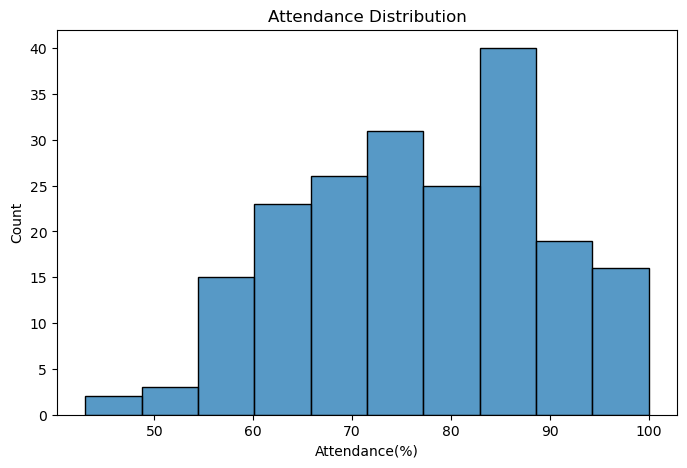

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Attendance(%)'], bins=10)

plt.title("Attendance Distribution")

plt.show()

### Success Probability Distribution

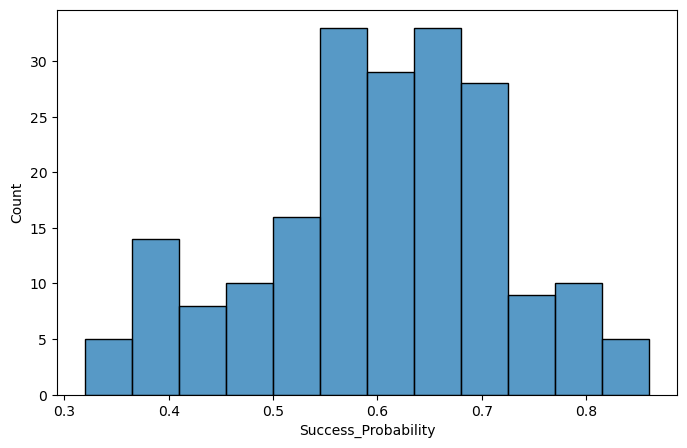

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Success_Probability'])

plt.show()

### Department-wise Distribution

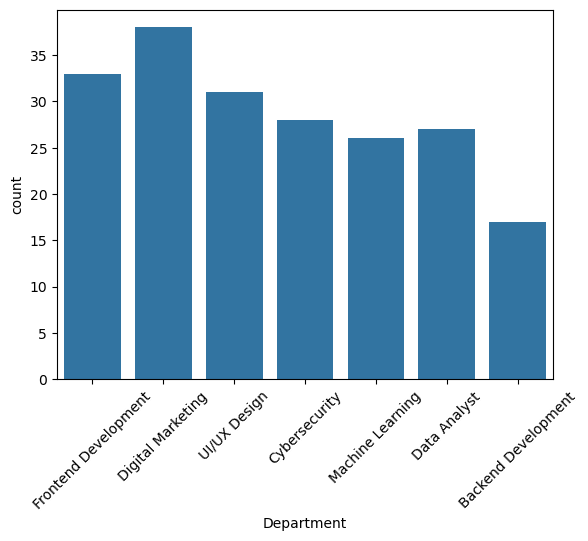

In [12]:
sns.countplot(x='Department', data=df)

plt.xticks(rotation=45)

plt.show()

### Performance Label Distribution

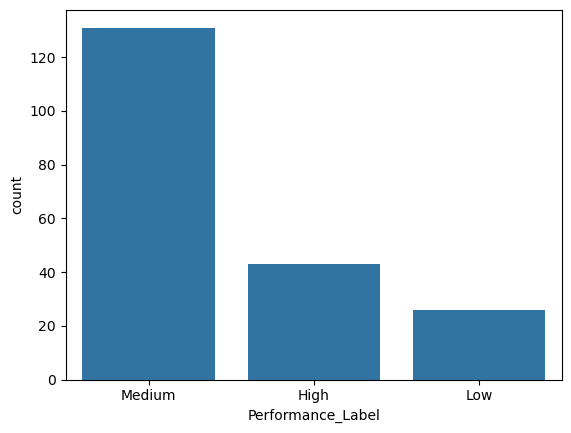

In [13]:
sns.countplot(x='Performance_Label', data=df)

plt.show()

### Correlation Heatmap

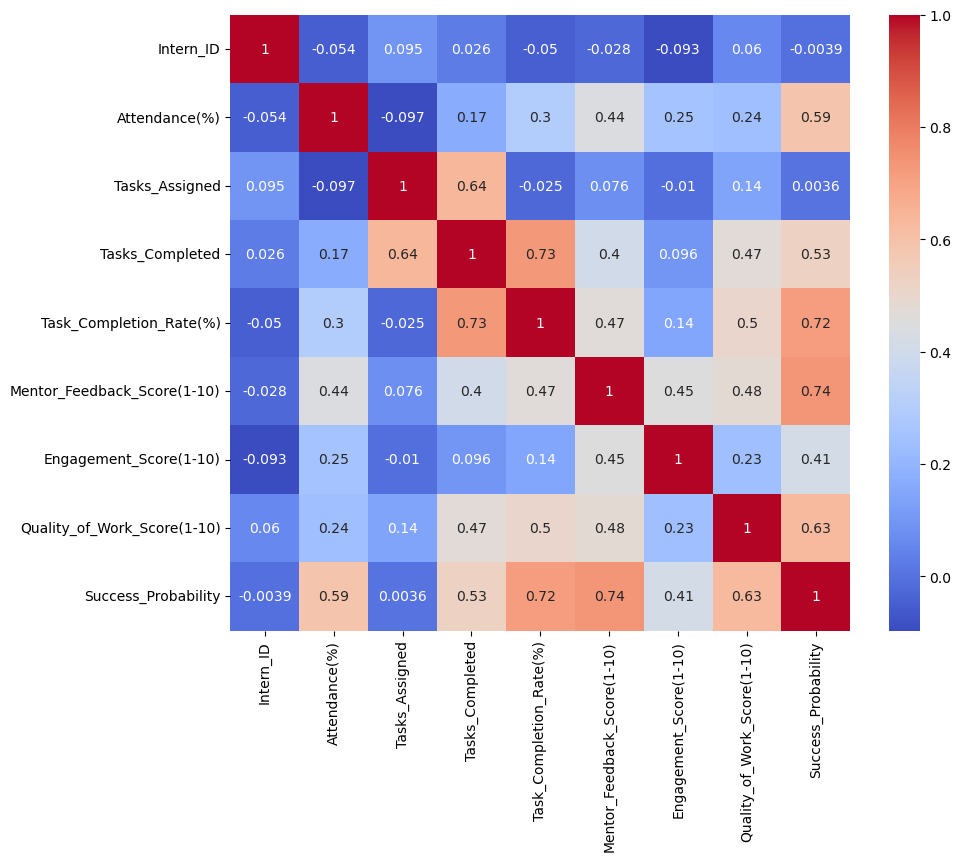

In [14]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

## Step 7: Data Preprocessing

Categorical variables are converted into numerical format using One-Hot Encoding so that they can be used by the machine learning model.

In [15]:
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

## Step 8: Feature Selection

The input features (X) and target variable (y) are selected for model training.

In [16]:
X = df.drop(['Intern_ID','Success_Probability','Performance_Label'], axis=1)

In [17]:
y = df['Success_Probability']

## Step 9: Split the Dataset

The dataset is divided into training and testing sets using an 80:20 ratio to evaluate the model on unseen data.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
80%

Training Data

20%

Testing Data

## Step 10: Build the Machine Learning Model

A Random Forest Regressor model is selected to predict the success probability of interns based on multiple performance-related features.

In [19]:
model = RandomForestRegressor(
    random_state=42
)

## Step 11: Train the Model

The model is trained using the training dataset to learn the relationship between the input features and the target variable.

In [20]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 12: Predict Success Probability

The trained model predicts the success probability of interns using the testing dataset.

In [21]:
y_pred = model.predict(X_test)

## Step 13: Evaluate Model Performance

**MAE**

In [22]:
mae = mean_absolute_error(y_test, y_pred)

print(mae)

0.04686250000000002


**MSE**

In [23]:
mse = mean_squared_error(y_test, y_pred)

print(mse)

0.0035228327500000044


**RMSE**

In [24]:
rmse = np.sqrt(mse)

print(rmse)

0.059353456091452705


**R² Score**

In [25]:
r2 = r2_score(y_test, y_pred)

print(r2)

0.7444618655786011


### Model Evaluation Results

- Mean Absolute Error (MAE): **0.0469**
- Mean Squared Error (MSE): **0.0035**
- Root Mean Squared Error (RMSE): **0.0594**
- R² Score: **0.7445**

## Step 14: Feature Importance Analysis

Feature importance analysis identifies the most influential factors affecting intern success probability.

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
4,Mentor_Feedback_Score(1-10),0.469583
3,Task_Completion_Rate(%),0.262760
0,Attendance(%),0.101700
6,Quality_of_Work_Score(1-10),0.074969
5,Engagement_Score(1-10),0.041661
2,Tasks_Completed,0.014128
1,Tasks_Assigned,0.012459
12,Department_UI/UX Design,0.005806
11,Department_Machine Learning,0.005388
9,Department_Digital Marketing,0.003881


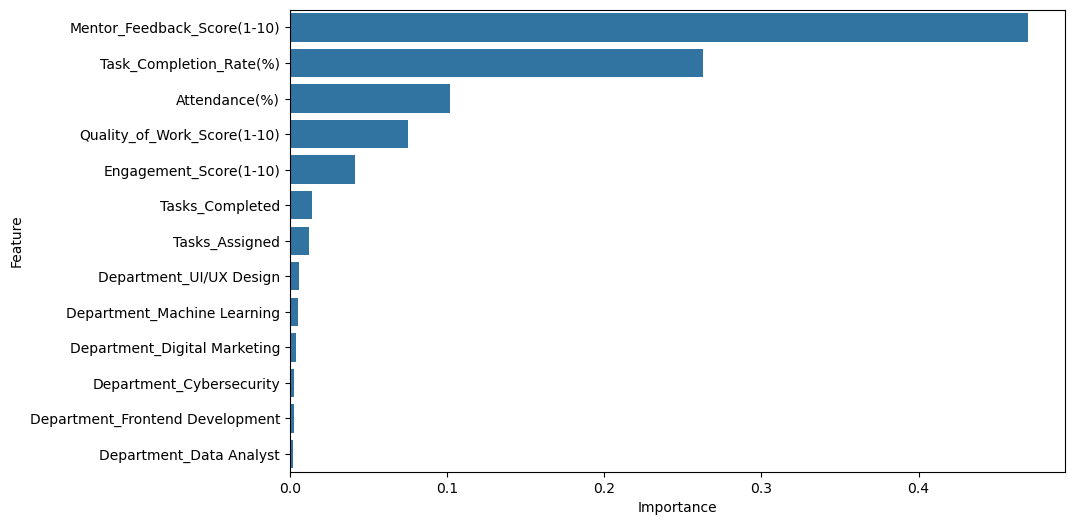

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.show()

## Step 15: Predict a New Intern

The trained model is used to predict the success probability of a new intern based on the provided input values.

In [30]:
new_intern = pd.DataFrame(0, index=[0], columns=X.columns)

In [31]:
new_intern['Attendance(%)'] = 90
new_intern['Tasks_Assigned'] = 20
new_intern['Tasks_Completed'] = 18
new_intern['Task_Completion_Rate(%)'] = 90
new_intern['Mentor_Feedback_Score(1-10)'] = 9
new_intern['Engagement_Score(1-10)'] = 8
new_intern['Quality_of_Work_Score(1-10)'] = 9

In [32]:
new_intern['Department_Data Analyst'] = 1

In [33]:
prediction = model.predict(new_intern)

print(prediction)

[0.8035]


In [34]:
print("Predicted Success Probability:", round(prediction[0] * 100, 2), "%")

Predicted Success Probability: 80.35 %


### Prediction Result

The predicted success probability for the new intern is **80.35%**, indicating a high likelihood of successful internship performance.

## Step 16: Insights

### Key Insights

- Interns with higher attendance generally achieve better performance.
- Completing assigned tasks significantly increases the success probability.
- Positive mentor feedback strongly contributes to intern success.
- Higher engagement scores are associated with improved internship outcomes.
- Quality of work is an important factor in predicting intern performance.
- The Random Forest Regressor demonstrated good predictive performance with an R² Score of **74.45%**.
- The model can assist mentors in identifying interns who may require additional support and personalized guidance.

# Conclusion

This project successfully developed a Machine Learning model to predict intern success probability using attendance, task completion, mentor feedback, engagement, and quality of work. The Random Forest Regressor achieved reliable predictive performance with an R² Score of **74.45%** and a low prediction error. The results indicate that attendance, task completion, mentor feedback, engagement, and work quality are key factors influencing intern success. This predictive model can support mentors in monitoring intern progress and providing timely, personalized guidance to improve overall internship outcomes.